<a href="https://colab.research.google.com/github/SinghBibushan/AI-and-ML/blob/main/Workshop0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

Cell 2 — Softmax and Prediction Functions

In [ ]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
    z (numpy.ndarray): Logits of shape (m, n)

    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n)
    """
    z = np.array(z, dtype=np.float64)
    z_stable = z - np.max(z, axis=1, keepdims=True)   # numerical stability
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def predict_softmax(X, W, b):
    """
    Predict class labels using trained softmax model.
    """
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    predicted_classes = np.argmax(probs, axis=1)
    return predicted_classes

Cell 3 — Test Softmax and Prediction

In [ ]:
# Softmax test
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")

# Prediction test
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

y_pred_test = predict_softmax(X_test, W_test, b_test)

assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"
print("Predicted class labels:", y_pred_test)

Softmax function passed the test case!
Predicted class labels: [1 1 0]


Cell 4 — Loss and Cost Functions

In [ ]:
def loss_softmax(y_pred, y):
    """
    Compute categorical cross-entropy loss.
    Supports single sample or batch input.
    """
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(np.sum(y * np.log(y_pred), axis=1))
    return loss


def cost_softmax(X, y, W, b):
    """
    Compute average softmax regression cost over all samples.
    """
    n = X.shape[0]
    logits = np.dot(X, W) + b
    y_pred = softmax(logits)
    total_loss = -np.sum(y * np.log(np.clip(y_pred, 1e-15, 1 - 1e-15)))
    return total_loss / n

Cell 5 — Test Loss and Cost

In [ ]:
# Loss test
y_true_correct = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct = np.array([
    [0.9, 0.05, 0.05],
    [0.1, 0.85, 0.05],
    [0.05, 0.1, 0.85]
])

y_pred_incorrect = np.array([
    [0.05, 0.05, 0.9],
    [0.1, 0.05, 0.85],
    [0.85, 0.1, 0.05]
])

loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")


# Cost test
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957
Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


Cell 6 — Gradient and Gradient Descent

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of the cost function with respect to W and b.
    """
    n = X.shape[0]
    logits = np.dot(X, W) + b
    y_pred = softmax(logits)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b


def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize weights and biases.
    """
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i+1}/{n_iter}, Cost: {cost:.6f}")

    return W, b, cost_history

Cell 7 — Test Gradient Function

In [ ]:
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


Cell 8 — Load and Prepare MNIST CSV

In [ ]:
def plot_sample_images(X, y):
    """
    Plot one sample image for each digit class (0-9).
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)

    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)

        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets,
    and plots one image per class.
    """
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values
    X = df.iloc[:, 1:].values

    X = X / 255.0

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

Cell 9 — Upload CSV in Colab

Saving mnist_dataset.csv to mnist_dataset.csv


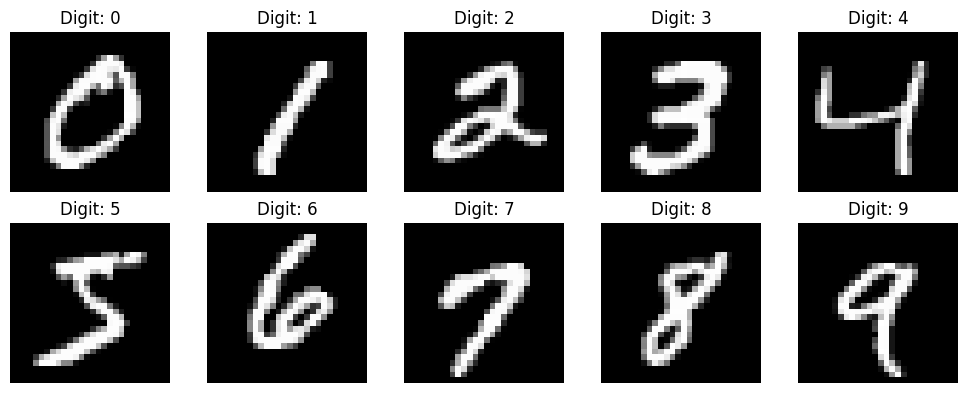

Move forward: Dimension of Feature Matrix X and label vector y matched.


In [ ]:
from google.colab import files
uploaded = files.upload()
csv_file = "mnist_dataset.csv"   # change this to your uploaded CSV filename

X_train, X_test, y_train, y_test = load_and_prepare_mnist(csv_file)

assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Cell 10 — One-Hot Encoding and Training

Iteration 1/1000, Cost: 2.220247
Iteration 101/1000, Cost: 0.608672
Iteration 201/1000, Cost: 0.490325
Iteration 301/1000, Cost: 0.441507
Iteration 401/1000, Cost: 0.413312
Iteration 501/1000, Cost: 0.394369
Iteration 601/1000, Cost: 0.380494
Iteration 701/1000, Cost: 0.369746
Iteration 801/1000, Cost: 0.361090
Iteration 901/1000, Cost: 0.353915
Iteration 1000/1000, Cost: 0.347891


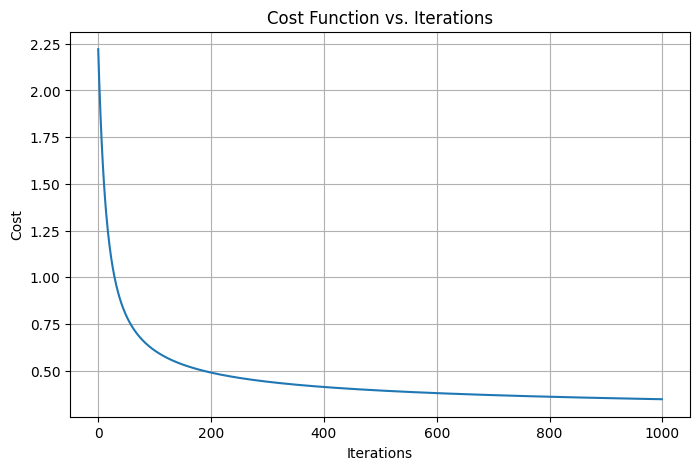

In [ ]:
# One-hot encode labels if needed
if len(y_train.shape) == 1:
    try:
        encoder = OneHotEncoder(sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(sparse=False)

    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test = encoder.transform(y_test.reshape(-1, 1))

d = X_train.shape[1]
c = y_train.shape[1]

np.random.seed(42)
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

alpha = 0.1
n_iter = 1000

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

Cell 11 — Evaluate the Model

First 5 rows:
   label  pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  \
0      5        0        0        0        0        0        0        0   
1      0        0        0        0        0        0        0        0   
2      4        0        0        0        0        0        0        0   
3      1        0        0        0        0        0        0        0   
4      9        0        0        0        0        0        0        0   

   pixel_7  pixel_8  ...  pixel_774  pixel_775  pixel_776  pixel_777  \
0        0        0  ...          0          0          0          0   
1        0        0  ...          0          0          0          0   
2        0        0  ...          0          0          0          0   
3        0        0  ...          0          0          0          0   
4        0        0  ...          0          0          0          0   

   pixel_778  pixel_779  pixel_780  pixel_781  pixel_782  pixel_783  
0          0          0         

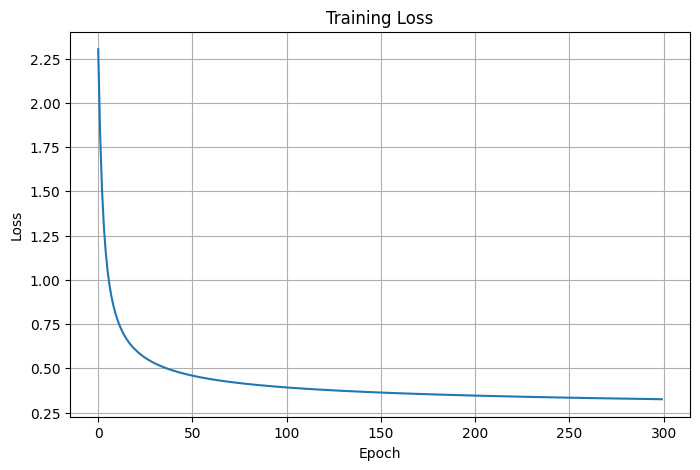

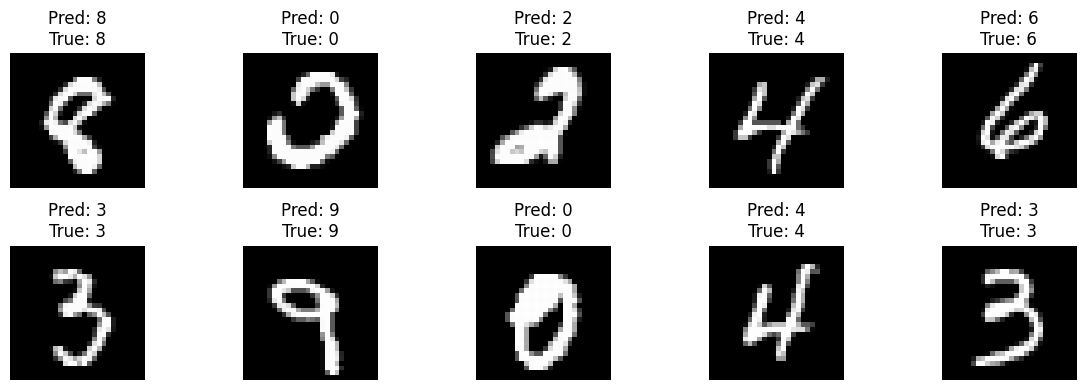

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score


# =========================
# 1. Load dataset
# =========================
file_path = "mnist_dataset.csv"   # your dataset file

df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns)

# Assumes the label column is named 'label'
X = df.drop(columns=["label"]).values.astype(np.float32)
y = df["label"].values.astype(int)

print("\nFeature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

# Normalize pixel values
X = X / 255.0


# =========================
# 2. One-hot encode labels
# =========================
def one_hot_encode(y, num_classes):
    y_one_hot = np.zeros((len(y), num_classes))
    y_one_hot[np.arange(len(y)), y] = 1
    return y_one_hot

num_classes = len(np.unique(y))
y_one_hot = one_hot_encode(y, num_classes)

print("Number of classes:", num_classes)
print("Unique labels:", np.unique(y))


# =========================
# 3. Train-test split
# =========================
X_train, X_test, y_train, y_test, y_train_raw, y_test_raw = train_test_split(
    X, y_one_hot, y, test_size=0.2, random_state=42, stratify=y
)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# =========================
# 4. Softmax helpers
# =========================
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(y_true, y_pred):
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

def predict_softmax(X, W, b):
    logits = np.dot(X, W) + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)


# =========================
# 5. Train softmax model
# =========================
def train_softmax(X, y, learning_rate=0.1, epochs=300):
    n_samples, n_features = X.shape
    n_classes = y.shape[1]

    W = np.zeros((n_features, n_classes), dtype=np.float32)
    b = np.zeros((1, n_classes), dtype=np.float32)

    loss_history = []

    for epoch in range(epochs):
        logits = np.dot(X, W) + b
        y_pred = softmax(logits)

        loss = compute_loss(y, y_pred)
        loss_history.append(loss)

        dW = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        db = (1 / n_samples) * np.sum(y_pred - y, axis=0, keepdims=True)

        W -= learning_rate * dW
        b -= learning_rate * db

        if (epoch + 1) % 50 == 0:
            train_labels = np.argmax(y, axis=1)
            pred_labels = np.argmax(y_pred, axis=1)
            acc = accuracy_score(train_labels, pred_labels)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    return W, b, loss_history


W_opt, b_opt, loss_history = train_softmax(
    X_train, y_train, learning_rate=0.5, epochs=300
)


# =========================
# 6. Evaluate
# =========================
def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    acc = accuracy_score(y_true, y_pred)
    return cm, precision, recall, f1, acc

y_pred_test = predict_softmax(X_test, W_opt, b_opt)

cm, precision, recall, f1, acc = evaluate_classification(y_test_raw, y_pred_test)

print("\nConfusion Matrix:")
print(cm)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


# =========================
# 7. Plot loss
# =========================
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# =========================
# 8. Show sample predictions
# =========================
sample_idx = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {y_pred_test[idx]}\nTrue: {y_test_raw[idx]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Cell 12 — Plot Confusion Matrix

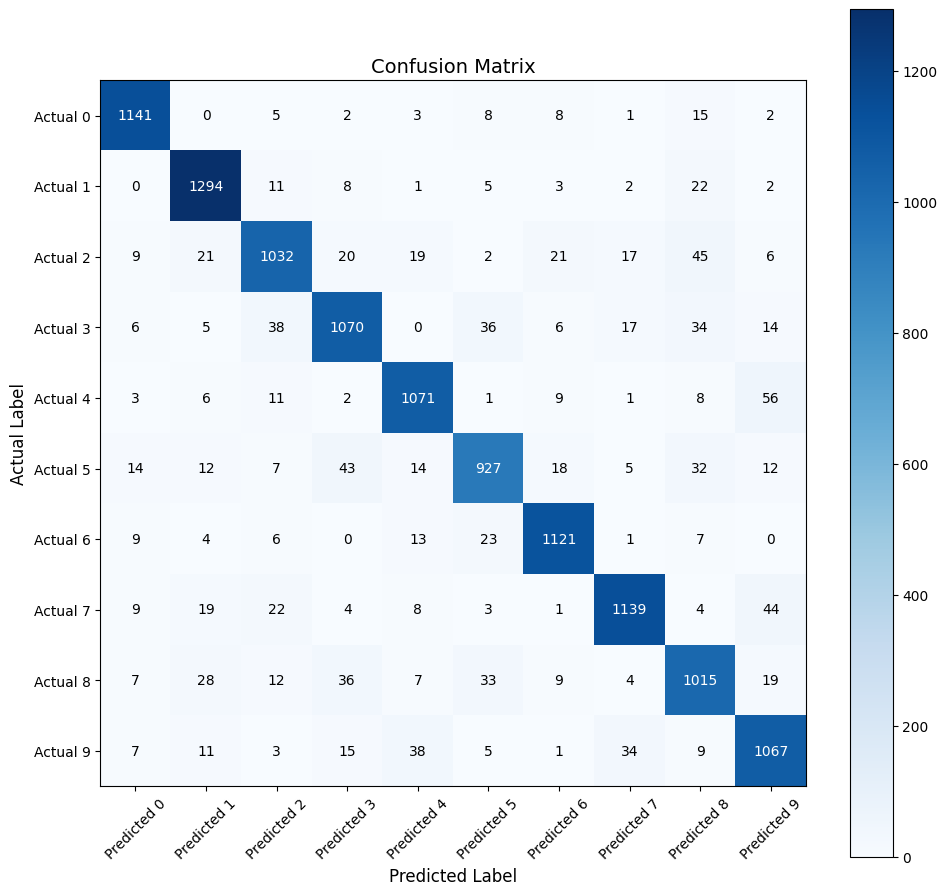

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)], rotation=45)
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

Cell 14 — Exercise 4: Linear Separability and Logistic Regression

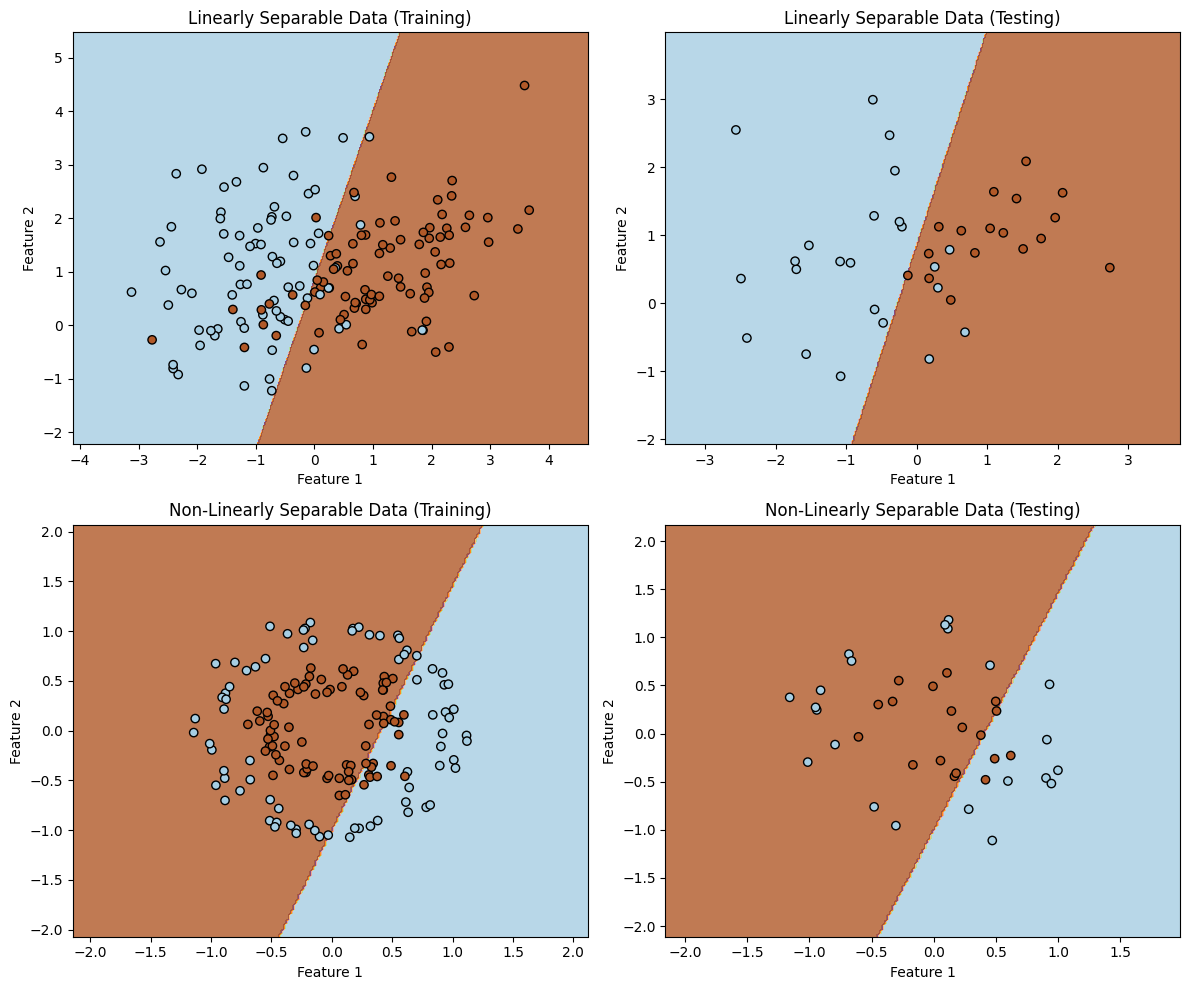

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.5,
    random_state=42
)

X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'Linearly Separable Data (Testing)'
)

plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()